# Trade Simulation: Quote Imbalance Signal

This notebook layers a trade simulation on top of the segmented-regression forecast
built in `analysis_MQ.ipynb`. We use only the execution primitives covered in class:

- **Aggressive (market) order** — crosses the spread; pays half-spread on entry
  and on exit (market–limit order duality).
- **Passive (limit) order** — posts on the favored side; gains half-spread if
  filled, exposed to **adverse selection** 

P&L is round-trip per share at horizon $\Delta t = 200$ ms (the
round-trip P&L is the only benchmark-independent P&L). 1 share per signal.

In [12]:
import sys
from data_loader import load_nbbosz
from imbalance import prepare_features
from forecast import filter_mid_change_events, optimize_cutoff
from simulation import simulate_aggressive, simulate_passive, summarize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Setup: train/simulate day pairs

For each pair we (i) compute the optimal cutoff $L^*$ on the train day, and
(ii) fire the simulator on the simulate day.

In [13]:
PAIRS = [
    ("2025-04-01", "2025-04-02"),
    ("2025-04-02", "2025-04-03"),
    ("2025-04-03", "2025-04-04"),
]
CUTOFFS = [0.6, 0.7, 0.8, 0.85, 0.9, 0.95]
HORIZON_MS = 200

## 2. Run the simulation across all 3 OOS pairs

In [14]:
agg_summaries, pas_summaries, fills = [], [], []
all_agg_trades, all_pas_trades = [], []
l_star_by_pair = {}

for train_date, sim_date in PAIRS:
    df_train = filter_mid_change_events(prepare_features(load_nbbosz(train_date, "../data")))
    _, l_star = optimize_cutoff(df_train, cutoffs=CUTOFFS)
    l_star_by_pair[train_date] = l_star

    df_sim = filter_mid_change_events(prepare_features(load_nbbosz(sim_date, "../data")))

    agg = simulate_aggressive(df_sim, l_star, horizon_ms=HORIZON_MS)
    pas, pas_diag = simulate_passive(df_sim, l_star, horizon_ms=HORIZON_MS)

    agg["pair"] = sim_date
    pas["pair"] = sim_date
    all_agg_trades.append(agg)
    all_pas_trades.append(pas)

    a = summarize(agg).assign(sim_date=sim_date)
    p = summarize(pas).assign(sim_date=sim_date)
    f = pas_diag["per_symbol"].assign(sim_date=sim_date)
    agg_summaries.append(a); pas_summaries.append(p); fills.append(f)

l_star_df = pd.DataFrame(l_star_by_pair)
print("Optimal cutoffs L* by training date:")
print(l_star_df.to_string())

Optimal cutoffs L* by training date:
      2025-04-01  2025-04-02  2025-04-03
sym                                     
AAL          0.7         0.7         0.8
BAC          0.8         0.7         0.6
DUK          0.6         0.6         0.6
HUM          0.6         0.6         0.6
TSLA         0.6         0.6         0.6


## 3. Compact comparison table per simulate-date and symbol

In [15]:
def compact(agg_summaries, pas_summaries, fills):
    A = pd.concat(agg_summaries).reset_index().set_index(["sim_date", "sym"])
    P = pd.concat(pas_summaries).reset_index().set_index(["sim_date", "sym"])
    F = pd.concat(fills).reset_index().set_index(["sim_date", "sym"])
    out = pd.DataFrame(index=A.index)
    out["spread_$"]    = A["mean_spread"].round(4)
    out["agg_n"]       = A["n_trades"].astype(int)
    out["agg_pnl_bps"] = A["mean_pnl_bps"].round(2)
    out["agg_total_$"] = A["total_pnl"].round(2)
    out["pas_fill%"]   = (F["fill_rate"] * 100).round(2)
    out["pas_n_fills"] = F["n_filled"].astype(int)
    out["pas_pnl_bps"] = P["mean_pnl_bps"].round(2)
    out["pas_total_$"] = P["total_pnl"].round(2)
    return out

table = compact(agg_summaries, pas_summaries, fills)
print(table.to_string())

                 spread_$   agg_n  agg_pnl_bps  agg_total_$  pas_fill%  pas_n_fills  pas_pnl_bps  pas_total_$
sim_date   sym                                                                                               
2025-04-02 AAL     0.0100   16467        -5.07       -87.65       0.09           15        -2.60        -0.04
           BAC     0.0100   28442        -1.33      -156.67       0.66          187        -2.15        -1.66
           DUK     0.0446    3426        -3.56      -147.15       4.81          165        -1.26        -2.46
           HUM     0.5568     510       -20.79      -279.38       5.05           26        -3.08        -1.70
           TSLA    0.0937  139965        -3.50    -13379.99      26.65        37310        -2.59     -2639.38
2025-04-03 AAL     0.0100   16309        -6.98      -110.34       0.63          103        -9.44        -0.96
           BAC     0.0101  110986        -1.74      -731.30       5.52         6126        -2.85       -66.66
          

## 4. Pooled P&L across the 3 OOS days

In [16]:
def pooled(trades):
    if trades.empty:
        return pd.DataFrame()
    return trades.groupby("sym").agg(
        n_trades=("pnl_per_share", "size"),
        hit_rate=("pnl_per_share", lambda x: (x > 0).mean()),
        mean_pnl_per_share=("pnl_per_share", "mean"),
        mean_pnl_bps=("pnl_bps", "mean"),
        total_pnl=("pnl_per_share", "sum"),
        mean_spread=("spread", "mean"),
    )

all_agg = pd.concat(all_agg_trades, ignore_index=True)
all_pas = pd.concat(all_pas_trades, ignore_index=True)

print("AGGRESSIVE -- pooled across 04-02, 04-03, 04-04")
print(pooled(all_agg).round(4).to_string())
print()
print("PASSIVE (filled trades only)")
print(pooled(all_pas).round(4).to_string())

AGGRESSIVE -- pooled across 04-02, 04-03, 04-04
      n_trades  hit_rate  mean_pnl_per_share  mean_pnl_bps  total_pnl  mean_spread
sym                                                                               
AAL      54840    0.0086             -0.0064       -6.6902    -352.45       0.0100
BAC     326393    0.0456             -0.0062       -1.7137   -2021.95       0.0101
DUK      18911    0.0167             -0.0521       -4.2816    -985.90       0.0550
HUM       3515    0.0023             -0.6907      -26.0935   -2427.92       0.7000
TSLA    327253    0.0440             -0.1111       -4.2673  -36366.07       0.1010

PASSIVE (filled trades only)
      n_trades  hit_rate  mean_pnl_per_share  mean_pnl_bps  total_pnl  mean_spread
sym                                                                               
AAL        155    0.0000             -0.0101      -10.4915      -1.56       0.0101
BAC      11734    0.0829             -0.0102       -2.7655    -119.17       0.0102
DUK      

## 5. Cumulative P&L plot

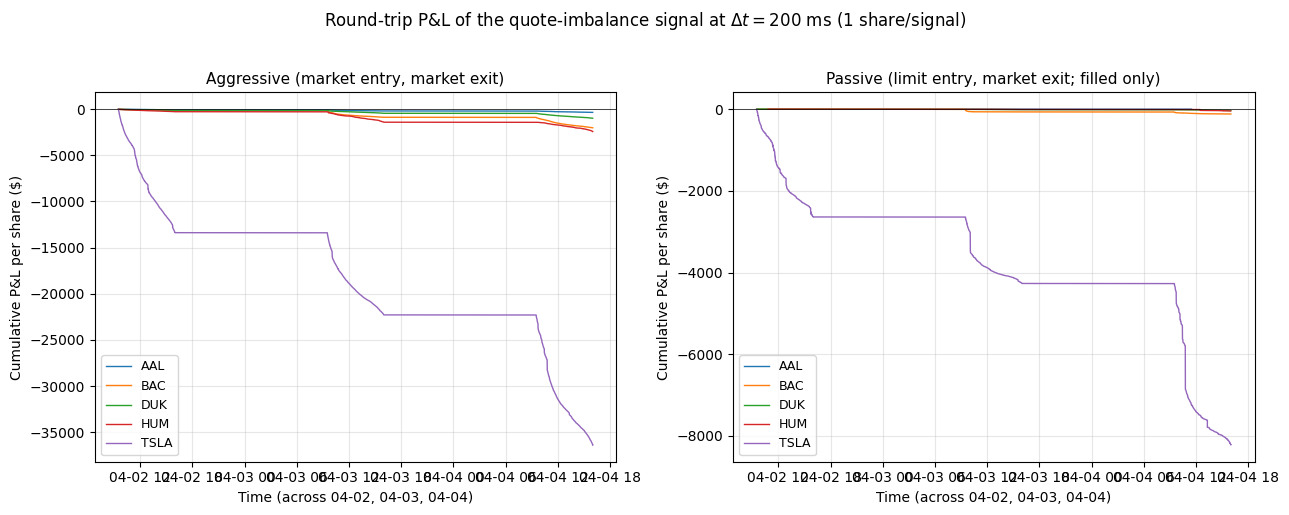

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, trades, title in [
    (axes[0], all_agg, "Aggressive (market entry, market exit)"),
    (axes[1], all_pas, "Passive (limit entry, market exit; filled only)"),
]:
    if trades.empty:
        ax.set_title(f"{title} -- no trades")
        continue
    t = trades.sort_values("tstamp").copy()
    t["cum_pnl"] = t.groupby("sym")["pnl_per_share"].cumsum()
    for sym, g in t.groupby("sym"):
        ax.plot(g["tstamp"].values, g["cum_pnl"].values, label=sym, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time (across 04-02, 04-03, 04-04)")
    ax.set_ylabel("Cumulative P&L per share ($)")
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(r"Round-trip P&L of the quote-imbalance signal at $\Delta t = 200$ ms (1 share/signal)",
             fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig("../figures/simulation_cumulative_pnl.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Interpretation 

**Aggressive**: every symbol, every OOS day, total P&L is negative. Mean P&L per share tracks the negative spread of the symbol (e.g. AAL spread \$0.01, mean P&L ≈ −\$0.006; HUM spread \$0.70, mean P&L ≈ −\$0.69). The signal has positive macro-F1 — direction is right more often than chance — but mid moves over 200 ms are smaller than the bid-ask spread. The signal does not pay for crossing it. This is exactly the half-spread cost of Lecture 7.

**Passive**: fill rates are tiny on penny-spread names (AAL ~0.3%, BAC ~3–6%, HUM ~5–8%) and only material for TSLA (~28%) and DUK (~7%). Even where fills happen, the half-spread saved on entry is more than offset by adverse selection: our bid is consumed precisely when the market is moving against us. P&L bps is negative across all five tickers — the textbook adverse-selection signature from Lecture 6, slide 18.

**Conclusion.** At a 200 ms horizon the alpha of the quote-imbalance signal is below the spread-crossing cost (aggressive) and below the adverse-selection cost (passive). The signal is a useful *direction forecaster* — F1 is well above the trivial classifier — but not a profitable *trading signal* in either execution mode without a wider horizon, larger cutoff, or a queue-aware execution policy.